### Imports

In [1]:
import os
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from skimage import exposure
import kagglehub
import glob
import imageio
from PIL import Image, ImageDraw, ImageFont


### Data Preprocessing

In [ ]:

# Download the Kaggle dataset
path = kagglehub.dataset_download("felicepollano/watermarked-not-watermarked-images")
print("Downloaded to:", path)

# The usable images are inside the subfolder "wm-nowm"
ROOT_DIR = os.path.join(dataset_path, "wm-nowm")
print("ROOT_DIR set to:", ROOT_DIR)

IMG_SIZE = 512
SAVE_OUTPUT_DIR = '/content/wm_results'
BATCH_VIS = 4

os.makedirs(SAVE_OUTPUT_DIR, exist_ok=True)


100%|██████████| 698M/698M [00:06<00:00, 112MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/felicepollano/watermarked-not-watermarked-images/versions/1
ROOT_DIR set to: /root/.cache/kagglehub/datasets/felicepollano/watermarked-not-watermarked-images/versions/1/wm-nowm


In [ ]:
base_path = os.path.join(path, "wm-nowm")

no_watermark_path = os.path.join(base_path, "train", "no-watermark")
watermark_path    = os.path.join(base_path, "train", "watermark")

print("No-watermark path:", no_watermark_path)
print("Watermark path:", watermark_path)

print("\nFinding matching image pairs...")

all_wm_images = glob.glob(os.path.join(watermark_path, "*.*"))
all_no_wm_images = glob.glob(os.path.join(no_watermark_path, "*.*"))

# extract file names
wm_filenames = {os.path.basename(p): p for p in all_wm_images}
no_wm_filenames = {os.path.basename(p): p for p in all_no_wm_images}

# maatch
matching_names = set(wm_filenames.keys()) & set(no_wm_filenames.keys())

matching_pairs = [
    {
        "filename": name,
        "watermark": wm_filenames[name],
        "no_watermark": no_wm_filenames[name]
    }
    for name in sorted(matching_names)
]

print("\n========================================")
print("MATCHING PAIRS SUMMARY")
print("========================================")
print(f"Total watermarked images:   {len(all_wm_images)}")
print(f"Total no-watermark images:  {len(all_no_wm_images)}")
print(f"Matching pairs found:       {len(matching_pairs)}")
print("========================================\n")

with open("matching_pairs.txt", "w") as f:
    f.write(f"Total matching pairs: {len(matching_pairs)}\n\n")
    for pair in matching_pairs:
        f.write(f"{pair['filename']}\n")
        f.write(f"  WM:  {pair['watermark']}\n")
        f.write(f"  NOWM:{pair['no_watermark']}\n\n")

print("✓ matching_pairs is now ready to use in the rest of the notebook!")


Using Colab cache for faster access to the 'watermarked-not-watermarked-images' dataset.
Downloaded to: /kaggle/input/watermarked-not-watermarked-images
No-watermark path: /kaggle/input/watermarked-not-watermarked-images/wm-nowm/train/no-watermark
Watermark path: /kaggle/input/watermarked-not-watermarked-images/wm-nowm/train/watermark

Finding matching image pairs...

MATCHING PAIRS SUMMARY
Total watermarked images:   12510
Total no-watermark images:  12477
Matching pairs found:       1743

✓ matching_pairs is now ready to use in the rest of the notebook!


### Helper functions

In [ ]:

def load_matching_pairs_from_list(matching_pairs, root_dir, img_size=IMG_SIZE):
    pairs = []

    for p in matching_pairs:
        wm = Path(root_dir) / p['watermark']
        clean = Path(root_dir) / p['no_watermark']
        if wm.exists() and clean.exists():
            pairs.append((str(wm), str(clean)))

    return pairs

def load_pairs_by_naming(root_dir, suffix_wm='_wm', suffix_clean='_clean', exts=('jpg','png','jpeg'), img_size=IMG_SIZE):
    root = Path(root_dir)
    files = list(root.glob('*'))
    base_map = {}

    for f in files:
        if f.suffix.lower().strip('.') in exts:
            name = f.stem
            base_map.setdefault(name, f)

    pairs = []
    for f in files:
        stem = f.stem
        if stem.endswith(suffix_wm):
            base = stem[:-len(suffix_wm)]
            clean_name = base + suffix_clean + f.suffix
            clean_path = root / clean_name
            if clean_path.exists():
                pairs.append((str(f), str(clean_path)))

    return pairs

def read_and_resize(path, size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_COLOR)

    if img is None:
        raise FileNotFoundError(f"Can't read {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if max(h,w) != size:
        scale = size / max(h,w)
        new_w = int(w*scale)
        new_h = int(h*scale)
        img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return img

# makes diff mask, returns mask
def make_diff_mask(wm_img, clean_img, thr=10):
    if wm_img.shape != clean_img.shape:
        clean_img = cv2.resize(clean_img, (wm_img.shape[1], wm_img.shape[0]), interpolation=cv2.INTER_AREA)

    diff = np.abs(wm_img.astype(int) - clean_img.astype(int))
    diff_mean = diff.mean(axis=2)
    mask = (diff_mean > thr).astype(np.uint8) * 255

    # morphological clean
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    return mask

# log detection for watermarks, returns binary mask
def log_detect_mask(img, gaussian_sigma=1.6, laplace_ksize=3, thresh=15, morph_kernel=3):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # gaussian blur
    ksize = int(max(3, 2 * round(3*gaussian_sigma) + 1))  # odd kernel
    blurred = cv2.GaussianBlur(gray, (ksize, ksize), gaussian_sigma)

    # laplacian
    lap = cv2.Laplacian(blurred, cv2.CV_64F, ksize=laplace_ksize)
    lap_abs = np.abs(lap)

    # normalize to 0-255 for thresholding
    lap_norm = (lap_abs / lap_abs.max() * 255).astype(np.uint8) if lap_abs.max() > 0 else lap_abs.astype(np.uint8)

    # threshold
    _, mask = cv2.threshold(lap_norm, thresh, 255, cv2.THRESH_BINARY)

    # clean
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel, morph_kernel))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    return mask

# combines log and diff masking
def refine_mask(log_mask, diff_mask, combine='or'):
    if combine == 'or':
        combined = cv2.bitwise_or(log_mask, diff_mask)
    elif combine == 'and':
        combined = cv2.bitwise_and(log_mask, diff_mask)
    elif combine == 'guided':
        # where diff indicates a watermark, keep it; else use LoG
        combined = np.where(diff_mask==255, 255, log_mask).astype(np.uint8)
    else:
        combined = cv2.bitwise_or(log_mask, diff_mask)
    # final morphological tidy
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel, iterations=2)
    combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel, iterations=1)
    return combined

# function to call inpaint
def inpaint_image(img_rgb, mask, method='telea', telea_radius=3):
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    if method == 'telea':
        flags = cv2.INPAINT_TELEA
    else:
        flags = cv2.INPAINT_NS
    inpainted_bgr = cv2.inpaint(img_bgr, mask, telea_radius, flags)
    return cv2.cvtColor(inpainted_bgr, cv2.COLOR_BGR2RGB)

def overlay_mask_on_image(img, mask, alpha=0.45):
    cmap = np.zeros_like(img)
    cmap[...,0] = mask  # red overlay
    over = img.copy()
    over = (over * (1-alpha) + cmap * alpha).astype(np.uint8)
    return over

def show_grid(list_imgs, titles=None, cols=4, figsize=(16,8)):
    n = len(list_imgs)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(list_imgs[i])
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


### Main pipeline

In [ ]:
# processes a single pair and returns dict with results/images
def process_pair(wm_path, clean_path,
                 gaussian_sigma=1.6, lap_ksize=3, log_thresh=18,
                 diff_thresh=10, combine_strategy='or', inpaint_method='telea'):

    wm_img = read_and_resize(wm_path, IMG_SIZE)
    clean_img = read_and_resize(clean_path, IMG_SIZE)

    diff_mask = make_diff_mask(wm_img, clean_img, thr=diff_thresh)
    log_mask = log_detect_mask(wm_img, gaussian_sigma=gaussian_sigma, laplace_ksize=lap_ksize, thresh=log_thresh, morph_kernel=3)
    combined_mask = refine_mask(log_mask, diff_mask, combine=combine_strategy)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    expanded = cv2.dilate(combined_mask, kernel, iterations=1)

    inpainted = inpaint_image(wm_img, expanded, method=inpaint_method, telea_radius=3)

    results = {
        'wm': wm_img,
        'clean': clean_img,
        'diff_mask': diff_mask,
        'log_mask': log_mask,
        'combined_mask': combined_mask,
        'expanded_mask': expanded,
        'inpainted': inpainted
    }
    return results


# Utility (safe reader/resizer)
def read_rgb(path, max_side=IMG_SIZE):
    im = cv2.imread(path, cv2.IMREAD_COLOR)
    if im is None:
        raise FileNotFoundError(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    h,w = im.shape[:2]
    if max(h,w) != max_side:
        scale = max_side / max(h,w)
        im = cv2.resize(im, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    return im

# Mask helpers
def make_gt_mask(wm, clean, thr=10):
    if wm.shape != clean.shape:
        clean = cv2.resize(clean, (wm.shape[1], wm.shape[0]), interpolation=cv2.INTER_AREA)
    diff = np.abs(wm.astype(int) - clean.astype(int)).mean(axis=2)
    mask = (diff > thr).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    return mask

def log_pipeline(img_rgb, gaussian_sigma=1.6, lap_ksize=3, thresh=15):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    # blur
    ksize = int(max(3, 2 * round(3*gaussian_sigma) + 1))
    blurred = cv2.GaussianBlur(gray, (ksize,ksize), gaussian_sigma)
    # laplacian
    lap = cv2.Laplacian(blurred, cv2.CV_64F, ksize=lap_ksize)
    lap_abs = np.abs(lap)
    lap_norm = (lap_abs / (lap_abs.max() + 1e-9) * 255).astype(np.uint8)
    _, mask = cv2.threshold(lap_norm, thresh, 255, cv2.THRESH_BINARY)
    # morph clean
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    return {
        "gray": gray,
        "blurred": blurred,
        "lap": lap,
        "lap_norm": lap_norm,
        "log_mask": mask
    }

def refine_masks(gt_mask, log_mask, combine='or'):
    if combine=='or':
        combined = cv2.bitwise_or(gt_mask, log_mask)
    elif combine=='and':
        combined = cv2.bitwise_and(gt_mask, log_mask)
    else:
        combined = np.where(gt_mask==255, 255, log_mask).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel, iterations=2)
    combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel, iterations=1)
    return combined

def feather_mask(mask, radius=7):
    # soft feather by Gaussian blur on float mask
    m = (mask/255.0).astype(np.float32)
    k = int(2*round(radius) + 1)
    m_blur = cv2.GaussianBlur(m, (k,k), radius)
    m_blur = np.clip(m_blur, 0, 1)
    # convert to 0..255 but keep float for visualization (we'll threshold later if needed)
    return (m_blur*255).astype(np.uint8)

def inpaint_rgb(img_rgb, mask, method='telea', radius=3):
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    if method=='telea':
        flag = cv2.INPAINT_TELEA
    else:
        flag = cv2.INPAINT_NS
    out = cv2.inpaint(img_bgr, mask, radius, flag)
    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)

# Visualization helper
def save_step_images(base_outdir, name, steps_dict):
    Path(base_outdir).mkdir(parents=True, exist_ok=True)
    for k,img in steps_dict.items():
        out_path = Path(base_outdir) / f"{name}__{k}.png"
        # convert grayscale float arrays where needed
        if img is None:
            continue
        if img.dtype != np.uint8:
            # normalize floats for saving
            vmin, vmax = np.min(img), np.max(img)
            if vmax - vmin > 1e-6:
                img_s = ((img - vmin) / (vmax - vmin) * 255).astype(np.uint8)
            else:
                img_s = (img*255).astype(np.uint8)
            if img_s.ndim==2:
                plt.imsave(out_path, img_s, cmap='gray')
            else:
                plt.imsave(out_path, img_s)
        else:
            if img.ndim==2:
                plt.imsave(out_path, img, cmap='gray')
            else:
                plt.imsave(out_path, img)

### Main Pipeline

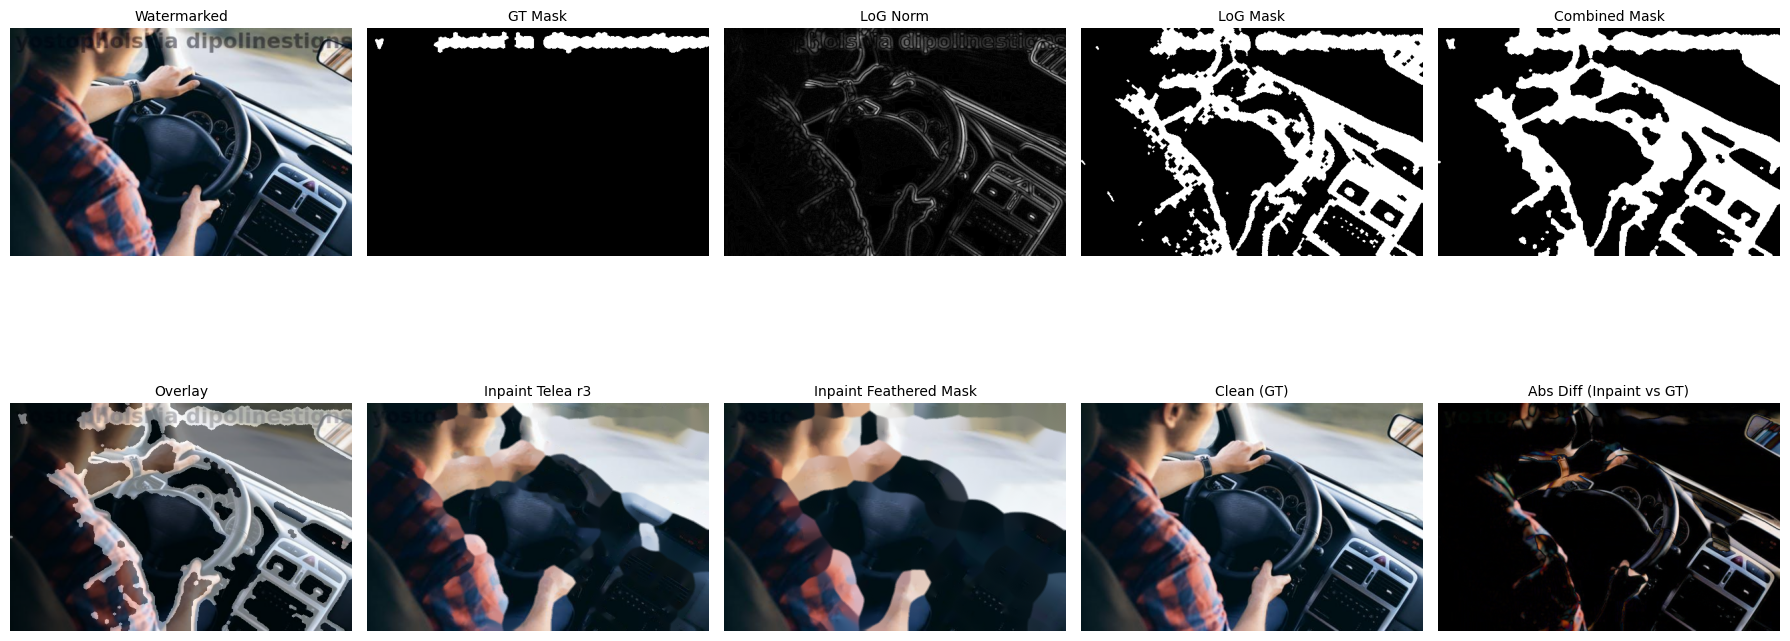

Step images saved to: /content/wm_results_steps/IMG_3496bfree/steps
You can include all files in that folder into a slide deck.


In [ ]:
# pick a pair to visualize (first matching pair)
if len(matching_pairs) == 0:
    raise RuntimeError("No matching_pairs found - run matching pair finder first.")

pair = matching_pairs[0]  # change index for others
wm_path = pair['watermark']
clean_path = pair['no_watermark']
base_name = Path(wm_path).stem
outdir = Path(SAVE_OUTPUT_DIR) / base_name / "steps"
outdir.mkdir(parents=True, exist_ok=True)

# read image
wm = read_rgb(wm_path, max_side=IMG_SIZE)
clean = read_rgb(clean_path, max_side=IMG_SIZE)

# diff
gt_mask = make_gt_mask(wm, clean, thr=10)

# LoG pipeline
log_steps = log_pipeline(wm, gaussian_sigma=1.6, lap_ksize=3, thresh=18)
log_mask = log_steps['log_mask']

combined_mask = refine_masks(gt_mask, log_mask, combine='or')

# inpaint
dilated = cv2.dilate(combined_mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)), iterations=1)
eroded = cv2.erode(combined_mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)), iterations=1)
feathered = feather_mask(combined_mask, radius=7)  # softer edges (uint8 float->blur)

inpaint_telea_r3 = inpaint_rgb(wm, combined_mask, method='telea', radius=3)
inpaint_ns_r3 = inpaint_rgb(wm, combined_mask, method='ns', radius=3)
inpaint_telea_r7 = inpaint_rgb(wm, dilated, method='telea', radius=7)
inpaint_feather = inpaint_rgb(wm, (feathered>20).astype(np.uint8)*255, method='telea', radius=3)  # use thresholded feather for inpaint mask

steps = {
    "watermarked": wm,
    "clean_gt": clean,
    "gt_mask": gt_mask,
    "log_gray": log_steps['gray'],
    "log_blurred": log_steps['blurred'],
    "log_laplacian_abs": np.abs(log_steps['lap']),
    "log_normalized": log_steps['lap_norm'],
    "log_mask": log_mask,
    "combined_mask": combined_mask,
    "dilated_mask": dilated,
    "eroded_mask": eroded,
    "feathered_mask": feathered,
    "overlay_combined": (overlay := (wm * 0.55 + np.stack([combined_mask]*3, axis=-1) * 0.45).astype(np.uint8)),
    "inpaint_telea_r3": inpaint_telea_r3,
    "inpaint_ns_r3": inpaint_ns_r3,
    "inpaint_telea_r7": inpaint_telea_r7,
    "inpaint_feather_mask": inpaint_feather,
    "abs_diff_inpaint_gt__telea_r3": np.abs(inpaint_telea_r3.astype(int) - clean.astype(int)).astype(np.uint8)
}

save_step_images(outdir, base_name, steps)

montage_list = [
    steps['watermarked'], steps['gt_mask'], steps['log_normalized'], steps['log_mask'],
    steps['combined_mask'], steps['overlay_combined'], steps['inpaint_telea_r3'], steps['inpaint_feather_mask'],
    steps['clean_gt'], steps['abs_diff_inpaint_gt__telea_r3']
]
titles = [
    "Watermarked", "GT Mask", "LoG Norm", "LoG Mask",
    "Combined Mask", "Overlay", "Inpaint Telea r3", "Inpaint Feathered Mask",
    "Clean (GT)", "Abs Diff (Inpaint vs GT)"
]

plt.figure(figsize=(18,9))
rows = 2
cols = 5
for i, img in enumerate(montage_list):
    ax = plt.subplot(rows, cols, i+1)
    if img.ndim==2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    ax.set_title(titles[i], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

print("Step images saved to:", outdir)
print("You can include all files in that folder into a slide deck.")


### Detailed visualization


WATERMARK DETECTION & REMOVAL DEMO

Processing: IMG_3496bfree.jpg
STEP-BY-STEP WATERMARK DETECTION & REMOVAL

[STEP 1] Loading original images...


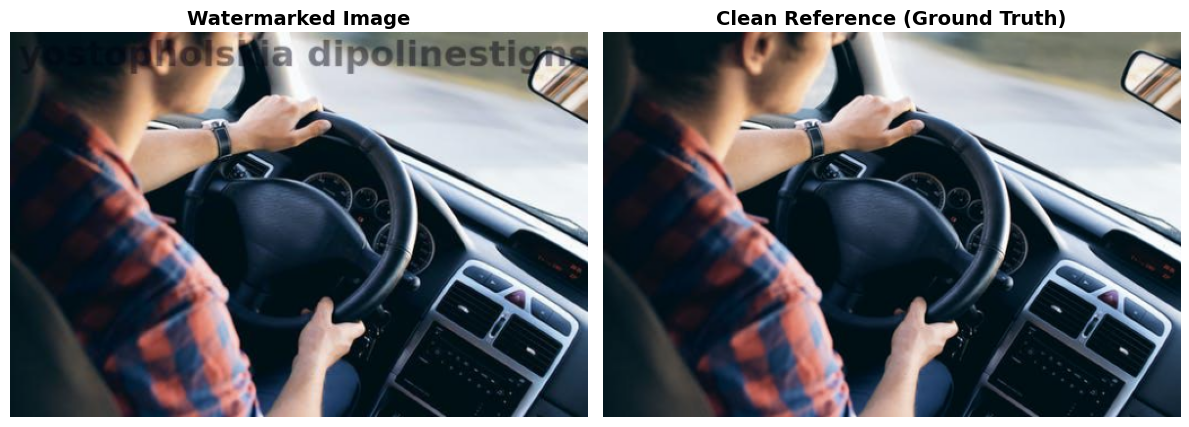

✓ Saved to presentation_output/step1_input_images.png

[STEP 2] Computing Difference Mask (requires clean reference)...


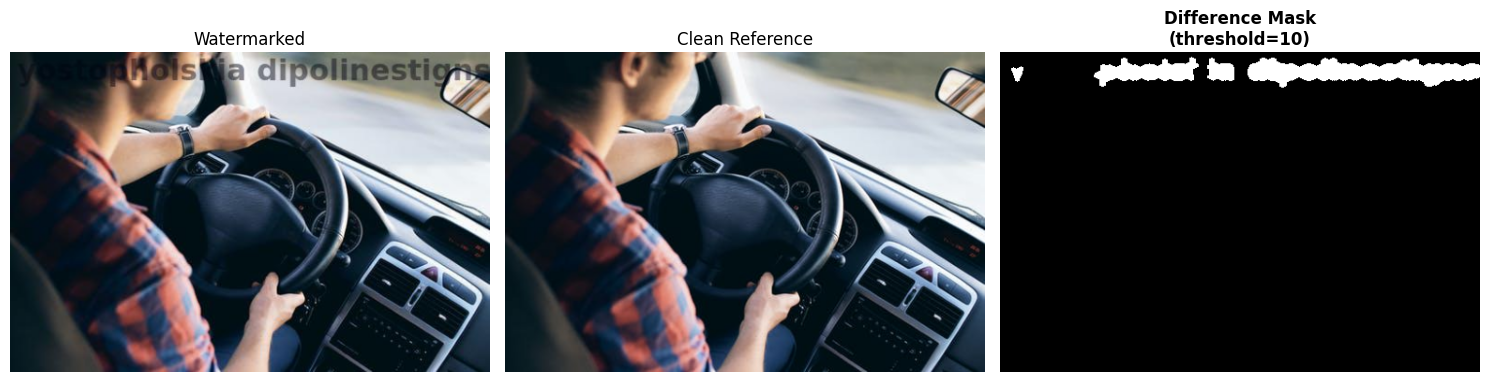

✓ Saved to presentation_output/step2_difference_mask.png
   Pixels detected: 7272

[STEP 3] Applying LoG (Laplacian of Gaussian) Detection...
   - Gaussian sigma: 1.6
   - Laplacian kernel size: 3
   - Threshold: 18


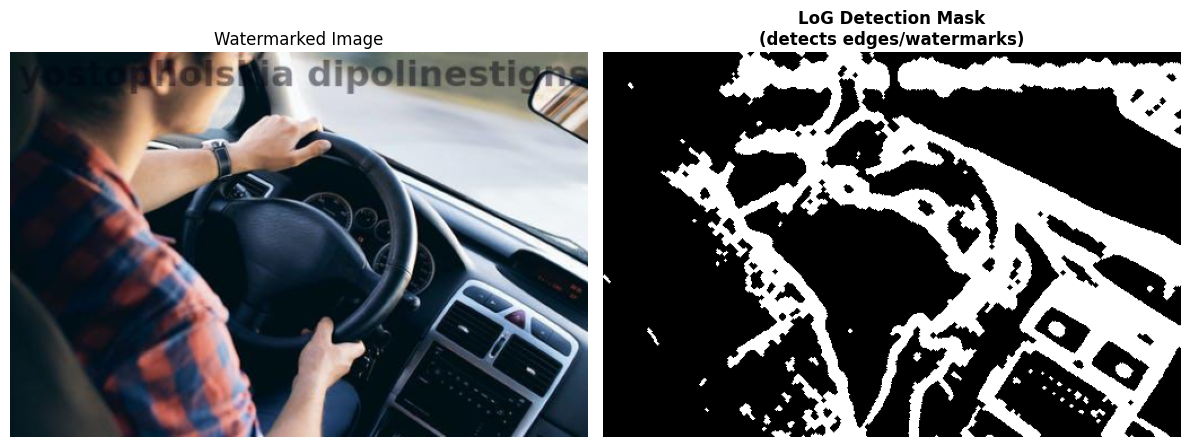

✓ Saved to presentation_output/step3_log_mask.png
   Pixels detected: 56105

[STEP 4] Comparing LoG Detection vs Ground Truth Difference...


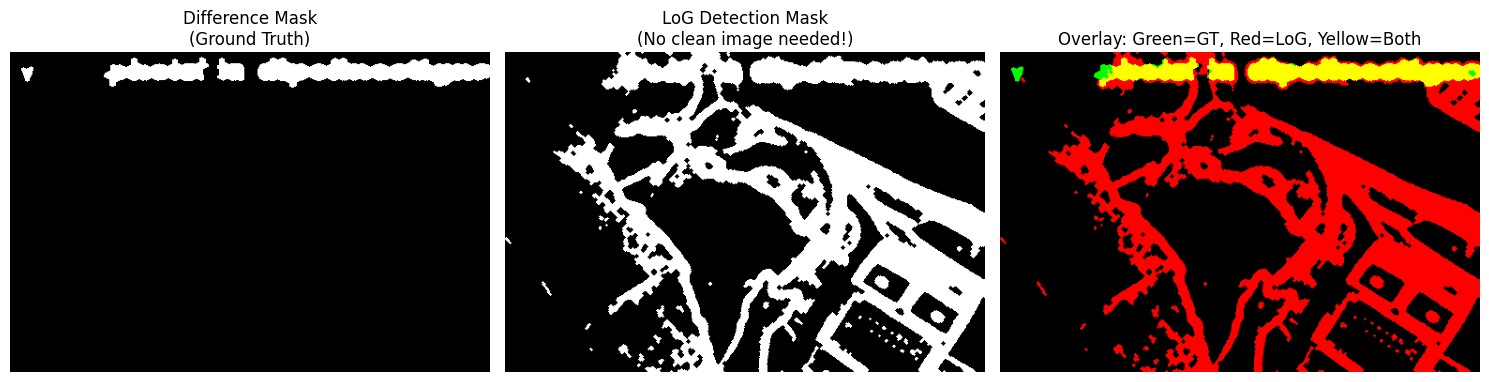

✓ Saved to presentation_output/step4_comparison.png

[STEP 5] Combining masks (strategy: or)...


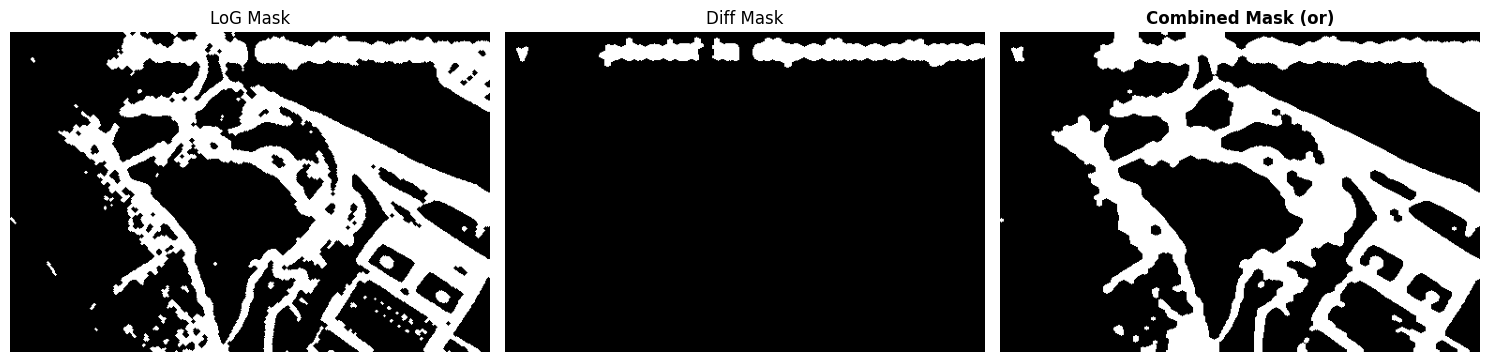

✓ Saved to presentation_output/step5_combined_mask.png

[STEP 6] Expanding mask to ensure full watermark coverage...


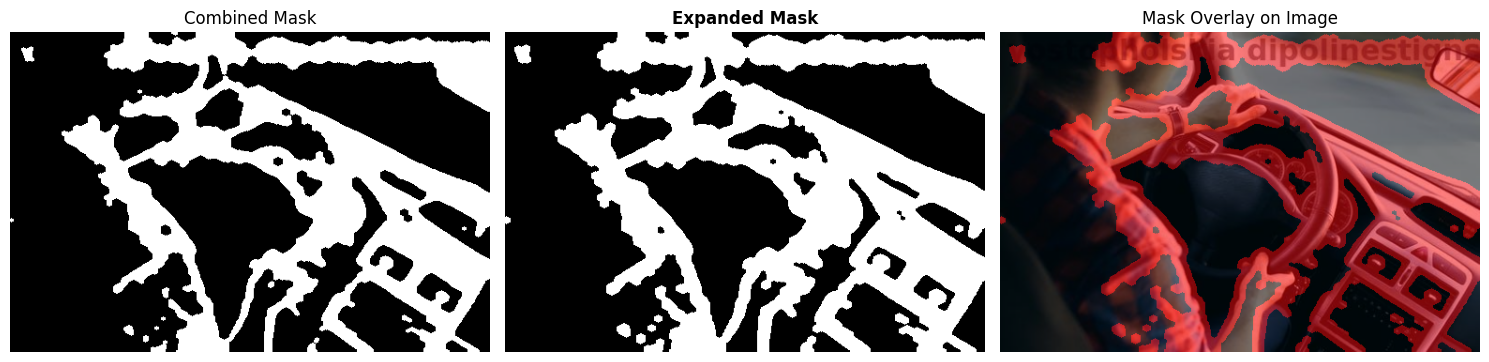

✓ Saved to presentation_output/step6_expanded_mask.png

[STEP 7] Inpainting (method: telea)...


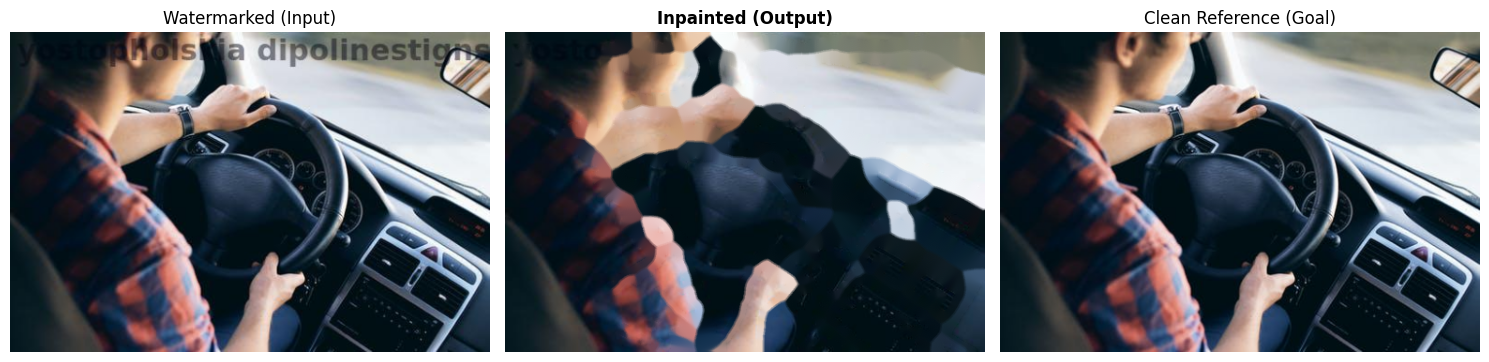

✓ Saved to presentation_output/step7_inpainting.png

[STEP 8] Final Results...


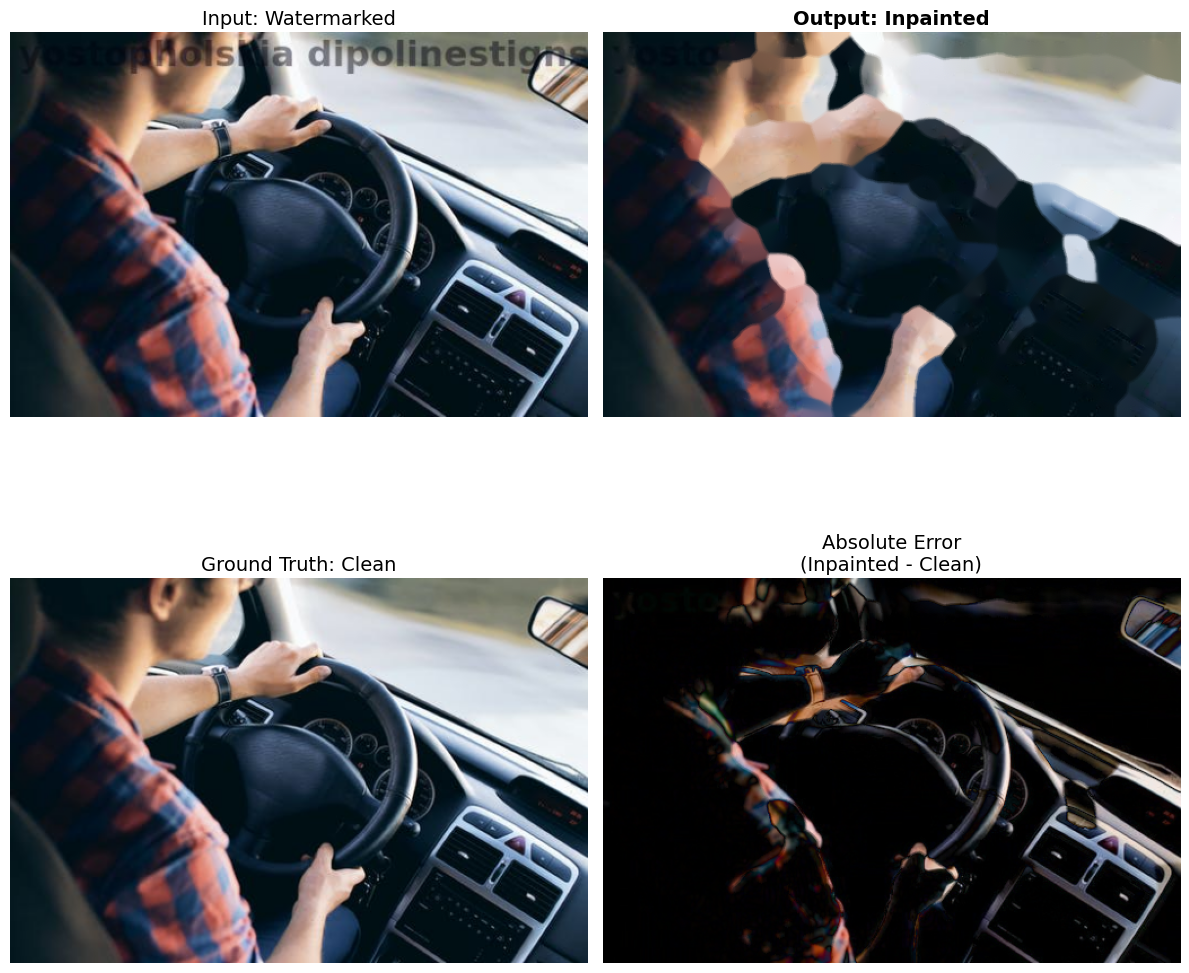

✓ Saved to presentation_output/step8_final_results.png

   Mean Squared Error: 2056.85
   (Lower is better, 0 = perfect)

✓ PIPELINE COMPLETE - All steps saved!

✓ All visualization steps saved to 'presentation_output/' folder!
  You can now add these images to your slides.


In [ ]:
def process_pair_with_steps(wm_path, clean_path,
                             gaussian_sigma=1.6, lap_ksize=3, log_thresh=18,
                             diff_thresh=10, combine_strategy='or', inpaint_method='telea',
                             save_dir='pipeline_steps'):

    os.makedirs(save_dir, exist_ok=True)

    wm_img = read_and_resize(wm_path, IMG_SIZE)
    clean_img = read_and_resize(clean_path, IMG_SIZE)

    print("\n[STEP 1] Loading original images...")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(wm_img)
    axes[0].set_title('Watermarked Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(clean_img)
    axes[1].set_title('Clean Reference (Ground Truth)', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/step1_input_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {save_dir}/step1_input_images.png")

    print("\n[STEP 2] Computing Difference Mask (requires clean reference)...")
    diff_mask = make_diff_mask(wm_img, clean_img, thr=diff_thresh)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(wm_img)
    axes[0].set_title('Watermarked', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(clean_img)
    axes[1].set_title('Clean Reference', fontsize=12)
    axes[1].axis('off')
    axes[2].imshow(diff_mask, cmap='gray')
    axes[2].set_title(f'Difference Mask\n(threshold={diff_thresh})', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/step2_difference_mask.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {save_dir}/step2_difference_mask.png")
    print(f"   Pixels detected: {np.sum(diff_mask == 255)}")

    print("\n[STEP 3] Applying LoG (Laplacian of Gaussian) Detection...")
    print(f"   - Gaussian sigma: {gaussian_sigma}")
    print(f"   - Laplacian kernel size: {lap_ksize}")
    print(f"   - Threshold: {log_thresh}")

    log_mask = log_detect_mask(wm_img, gaussian_sigma=gaussian_sigma,
                                laplace_ksize=lap_ksize, thresh=log_thresh, morph_kernel=3)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(wm_img)
    axes[0].set_title('Watermarked Image', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(log_mask, cmap='gray')
    axes[1].set_title(f'LoG Detection Mask\n(detects edges/watermarks)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/step3_log_mask.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {save_dir}/step3_log_mask.png")
    print(f"   Pixels detected: {np.sum(log_mask == 255)}")

    print("\n[STEP 4] Comparing LoG Detection vs Ground Truth Difference...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(diff_mask, cmap='gray')
    axes[0].set_title('Difference Mask\n(Ground Truth)', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(log_mask, cmap='gray')
    axes[1].set_title('LoG Detection Mask\n(No clean image needed!)', fontsize=12)
    axes[1].axis('off')

    comparison = np.zeros((*log_mask.shape, 3), dtype=np.uint8)
    comparison[diff_mask == 255] = [0, 255, 0]  # Green = ground truth
    comparison[log_mask == 255] = [255, 0, 0]   # Red = LoG detection
    comparison[(diff_mask == 255) & (log_mask == 255)] = [255, 255, 0]  # Yellow = both
    axes[2].imshow(comparison)
    axes[2].set_title('Overlay: Green=GT, Red=LoG, Yellow=Both', fontsize=12)
    axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/step4_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {save_dir}/step4_comparison.png")

    print(f"\n[STEP 5] Combining masks (strategy: {combine_strategy})...")
    combined_mask = refine_mask(log_mask, diff_mask, combine=combine_strategy)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(log_mask, cmap='gray')
    axes[0].set_title('LoG Mask', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(diff_mask, cmap='gray')
    axes[1].set_title('Diff Mask', fontsize=12)
    axes[1].axis('off')
    axes[2].imshow(combined_mask, cmap='gray')
    axes[2].set_title(f'Combined Mask ({combine_strategy})', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/step5_combined_mask.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {save_dir}/step5_combined_mask.png")

    print("\n[STEP 6] Expanding mask to ensure full watermark coverage...")
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    expanded = cv2.dilate(combined_mask, kernel, iterations=1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(combined_mask, cmap='gray')
    axes[0].set_title('Combined Mask', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(expanded, cmap='gray')
    axes[1].set_title('Expanded Mask', fontsize=12, fontweight='bold')
    axes[1].axis('off')

    overlay = overlay_mask_on_image(wm_img, expanded, alpha=0.5)
    axes[2].imshow(overlay)
    axes[2].set_title('Mask Overlay on Image', fontsize=12)
    axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/step6_expanded_mask.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {save_dir}/step6_expanded_mask.png")

    print(f"\n[STEP 7] Inpainting (method: {inpaint_method})...")
    inpainted = inpaint_image(wm_img, expanded, method=inpaint_method, telea_radius=3)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(wm_img)
    axes[0].set_title('Watermarked (Input)', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(inpainted)
    axes[1].set_title('Inpainted (Output)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    axes[2].imshow(clean_img)
    axes[2].set_title('Clean Reference (Goal)', fontsize=12)
    axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/step7_inpainting.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {save_dir}/step7_inpainting.png")

    print("\n[STEP 8] Final Results...")
    error = np.abs(inpainted.astype(int) - clean_img.astype(int)).astype(np.uint8)
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes[0,0].imshow(wm_img)
    axes[0,0].set_title('Input: Watermarked', fontsize=14)
    axes[0,0].axis('off')
    axes[0,1].imshow(inpainted)
    axes[0,1].set_title('Output: Inpainted', fontsize=14, fontweight='bold')
    axes[0,1].axis('off')
    axes[1,0].imshow(clean_img)
    axes[1,0].set_title('Ground Truth: Clean', fontsize=14)
    axes[1,0].axis('off')
    axes[1,1].imshow(error)
    axes[1,1].set_title('Absolute Error\n(Inpainted - Clean)', fontsize=14)
    axes[1,1].axis('off')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/step8_final_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {save_dir}/step8_final_results.png")

    mse = np.mean((inpainted.astype(float) - clean_img.astype(float))**2)
    print(f"\n   Mean Squared Error: {mse:.2f}")
    print(f"   (Lower is better, 0 = perfect)")

    print("\n" + "=" * 60)
    print("✓ PIPELINE COMPLETE - All steps saved!")
    print("=" * 60)

    results = {
        'wm': wm_img,
        'clean': clean_img,
        'diff_mask': diff_mask,
        'log_mask': log_mask,
        'combined_mask': combined_mask,
        'expanded_mask': expanded,
        'inpainted': inpainted,
        'error': error
    }
    return results


if len(matching_pairs) > 0:
    sample_pair = matching_pairs[0]

    print(f"\nProcessing: {sample_pair['filename']}")

    results = process_pair_with_steps(
        sample_pair['watermark'],
        sample_pair['no_watermark'],
        gaussian_sigma=1.6,
        lap_ksize=3,
        log_thresh=18,
        diff_thresh=10,
        combine_strategy='or',
        inpaint_method='telea',
        save_dir='presentation_output'
    )

    print("\n✓ All visualization steps saved to 'presentation_output/' folder!")
    print("  You can now add these images to your slides.")
else:
    print("No matching pairs found!")

## claude

### Result GIF Maker For Presentation

In [ ]:
import imageio
from PIL import Image, ImageDraw, ImageFont

def create_pipeline_gif(results, output_path='watermark_pipeline.gif', duration=5.0):
    frames = []

    # defined steps to show
    steps = [
        ('wm', 'Step 1: Watermarked Input'),
        ('log_mask', 'Step 2: LoG Detection Mask'),
        ('diff_mask', 'Step 3: Difference Mask (Ground Truth)'),
        ('combined_mask', 'Step 4: Combined Mask'),
        ('expanded_mask', 'Step 5: Expanded Mask'),
        ('inpainted', 'Step 6: Inpainted Result'),
        ('clean', 'Step 7: Clean Reference (Goal)')
    ]

    for key, title in steps:
        img_array = results[key]

        if len(img_array.shape) == 2:
            img_array = np.stack([img_array]*3, axis=-1)

        # convert to PIL image
        img = Image.fromarray(img_array.astype(np.uint8))

        draw = ImageDraw.Draw(img)
        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 20)
        except:
            font = ImageFont.load_default()

        text_bbox = draw.textbbox((10, 10), title, font=font)
        draw.rectangle(text_bbox, fill='black')
        draw.text((10, 10), title, fill='white', font=font)

        frames.append(np.array(img))

    # save as GIF
    imageio.mimsave(output_path, frames, duration=duration, loop=0)
    print(f"✓ GIF saved to {output_path}")

create_pipeline_gif(results, 'watermark_pipeline.gif', duration=5.0)

✓ GIF saved to watermark_pipeline.gif
